In [1]:
### Graphs from the computational section
# Libraries ------------------------

import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from scipy import stats
import mesa

# Plotting settings
import matplotlib.ticker as mtick
from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}

sns.set_palette([
    "#8E44AD",  # violet/purple
    "#C08081",  # muted pinkish/brown
    "#f97743",  # bright orange
    "#2f6edd",  # royal blue
    "#28b36a",  # green
    "#333333",  # dark gray
    "#1ABC9C",  # teal
    "#E74C3C",  # red
])
# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel



In [ ]:
# Model introductory graphs: networks ------
model_intro = statusgame_model(N=100, seed=666, lambda_s=1, memory=5,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=10, rho=1/3, seed_consumption=True, alpha=1/2, weights=[1/3, 1/3, 1/3])


nx.write_gexf(model_intro.G, "results/initial_network.gexf")


for _ in range(100):
    model_intro.step()
model_intro_df = model_intro.datacollector.get_agent_vars_dataframe().reset_index()

nx.write_gexf(model_intro.G, "results/final_network.gexf")

#model_intro_df.plot(x="index", y="cluster_coefficient") Non-trivial clustering

alpha = 0.001
alpha = 0.25075
alpha = 0.5005
alpha = 0.75025
alpha = 1.0


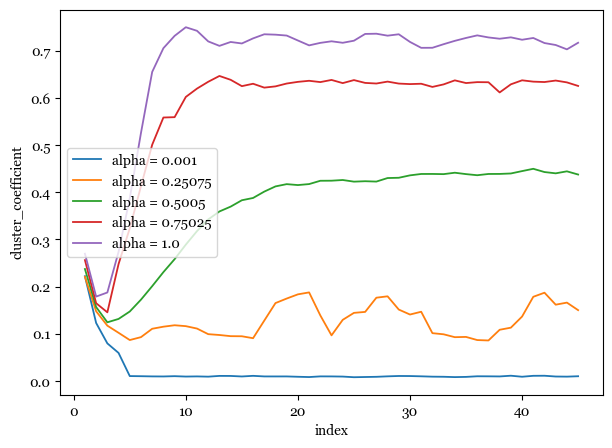

In [ ]:
# Graphs to showcase alpha on the network section ------
# Run test with many agents
runs_multi_alpha_all = {}

for alpha in np.linspace(0.001, 1, 5):
    all_agents_alpha = statusgame_model(N=1000, seed=666, lambda_s=1, memory=5,
        create_network="watts_strogatz", p=1/1000, gamma=1, k=5, rho=1/3, seed_consumption=True, alpha=alpha)
    
    for _ in range(45):
        all_agents_alpha.step()

    print(f"alpha = {alpha}")
    runs_multi_alpha_all[alpha] = all_agents_alpha.datacollector.get_model_vars_dataframe().reset_index()

# Store
pd.to_pickle(runs_multi_alpha_all, "results/alpha_runs.pkl")

# Plot
fig, ax = plt.subplots(figsize=(7,5))
for r in range(0,5):
    run = list(runs_multi_alpha_all.keys())[r]
    sns.lineplot(data=runs_multi_alpha_all[run].loc[runs_multi_alpha_all[run].index > 0], x="index", y="cluster_coefficient", label = r"$\alpha$ = {}".format(round(run,3)), ax = ax, linewidth = 1.3)
ax.set_xlabel("t")
ax.set_ylabel("Avg. Clustering Coefficient")
ax.set_title(r"Clustering Coefficient and $\alpha$")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig("results/alpha_clustering_coefficient.pdf", bbox_inches = "tight", dpi=300)


In [2]:
# Graph 1: Standard behavior of the model
model_prop_neutral = statusgame_model(N=400, seed=666, lambda_s=3/5, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=20, rho=1/2, seed_consumption=True, alpha=1/50, weights=[1/3, 1/3, 1/3])

for _ in range(100):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_agent_vars_dataframe().reset_index()

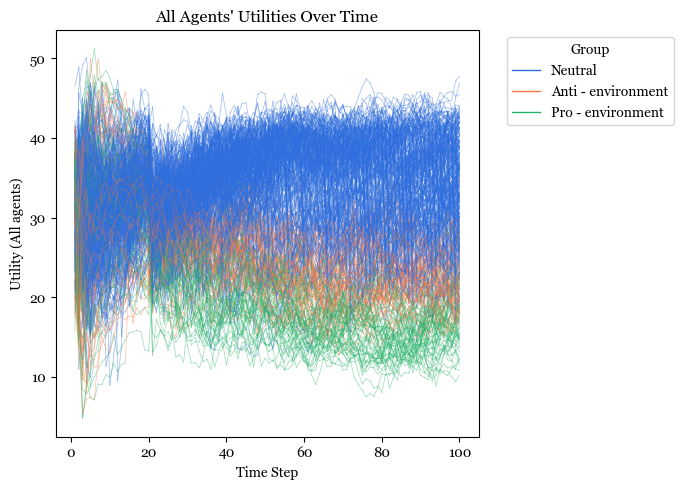

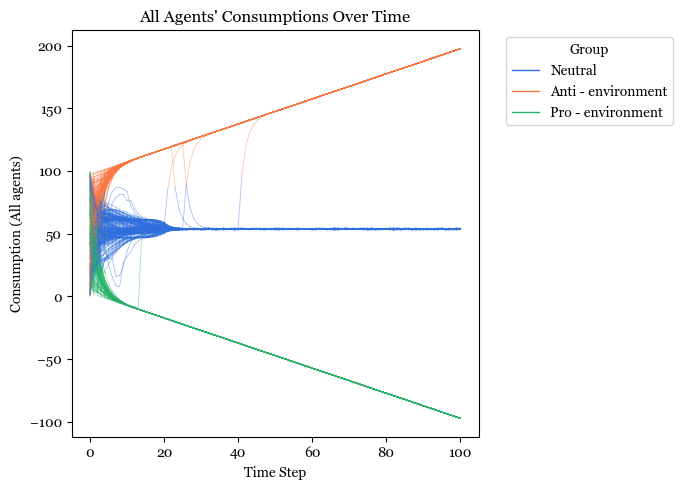

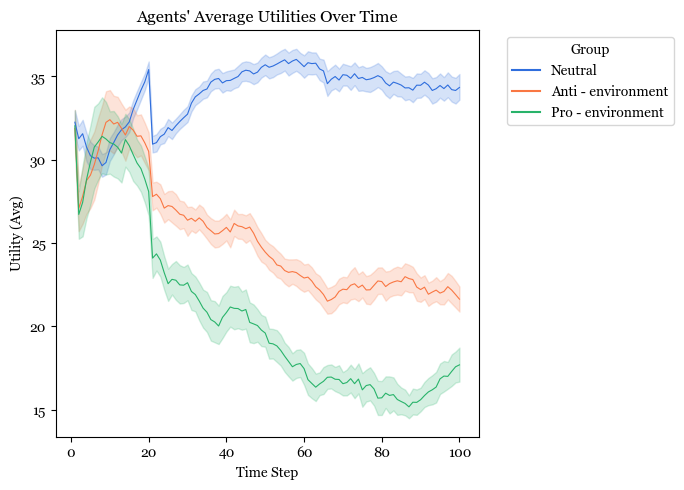

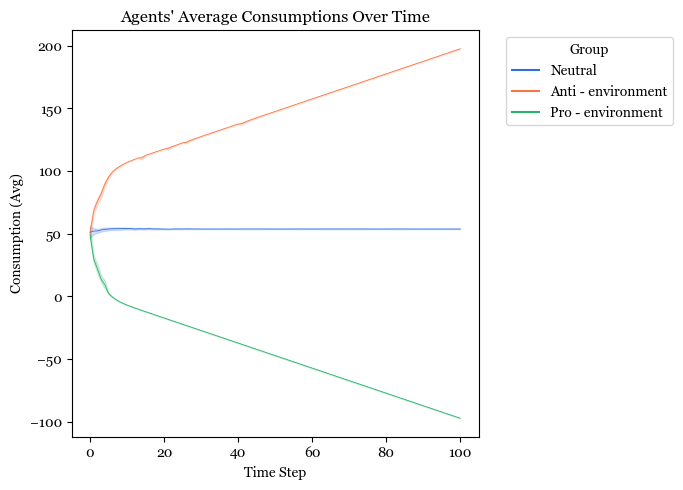

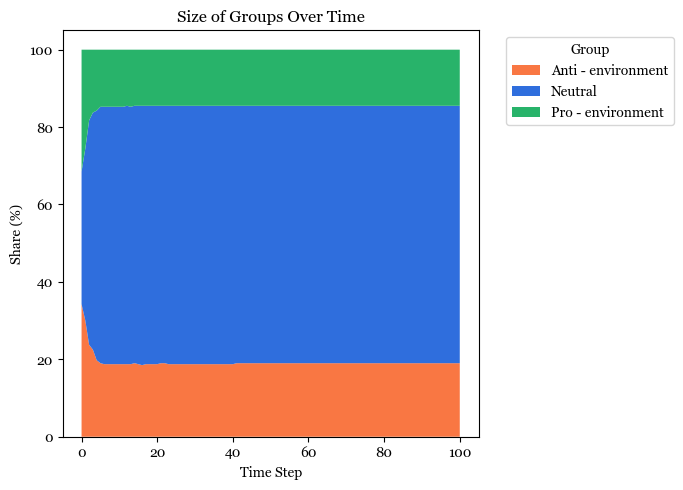

In [3]:
plot_all_agent_graphs(model_prop_neutral_df, color_dict, output_folder="results/fig1_computational", show_plots=True)

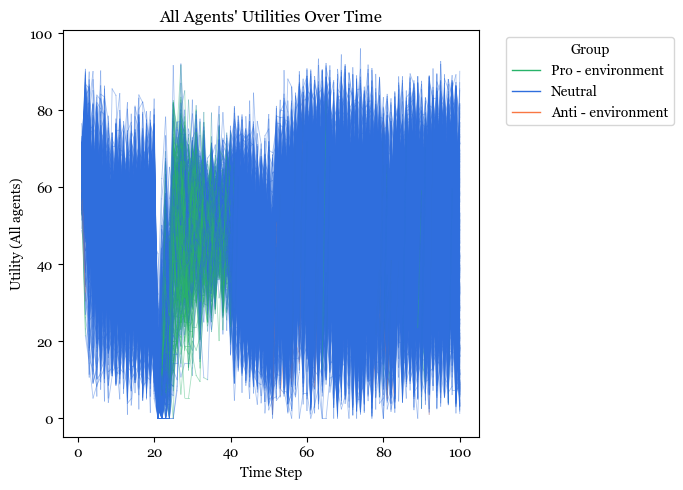

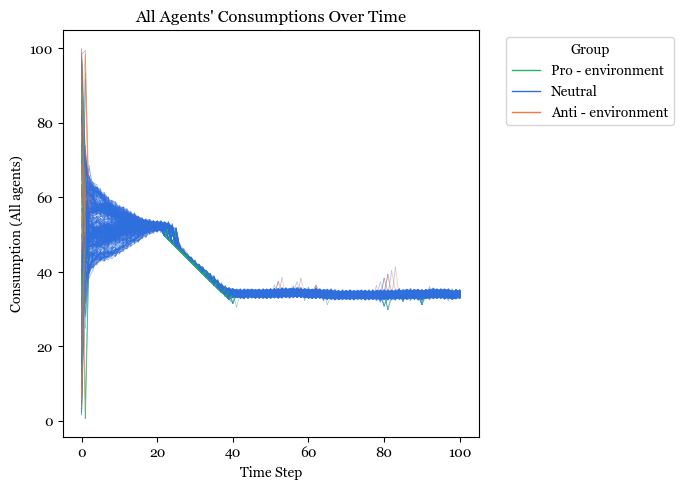

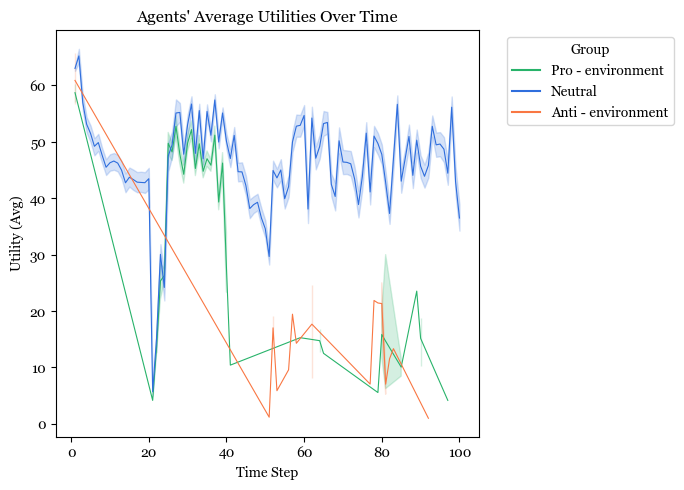

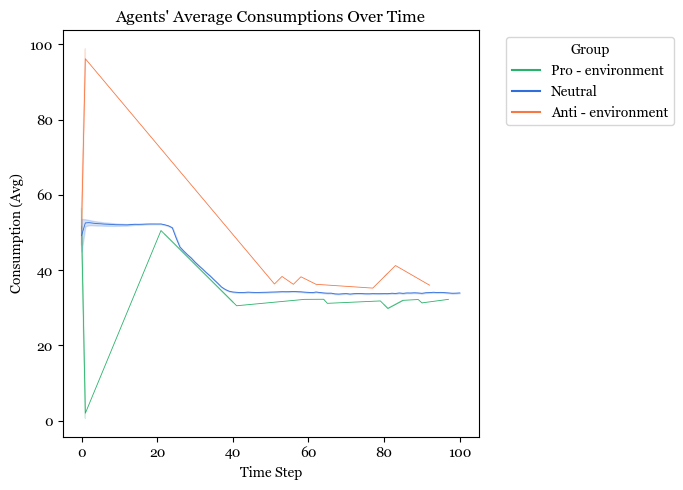

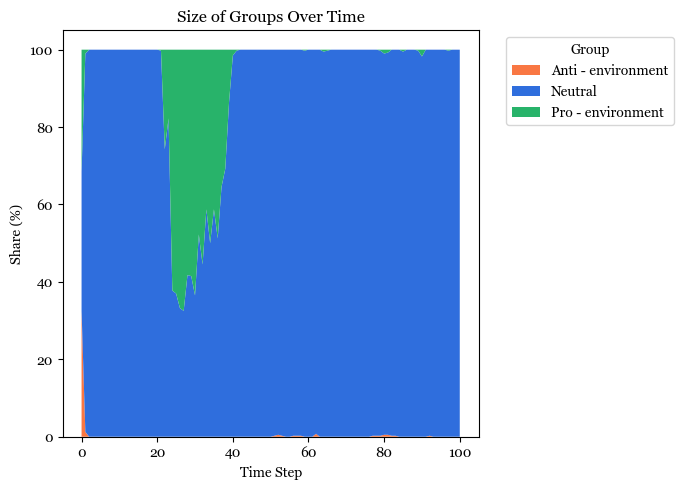

In [4]:
# Graph 2: Extreme initial conditions, everyone becomes neutral quickly 
model_prop_neutral = statusgame_model(N=400, seed=667, lambda_s=1, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=1, k=20, rho=1/3, seed_consumption=True, alpha=1/50, weights=[1/3, 1/3, 1/3])

for _ in range(100):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_agent_vars_dataframe().reset_index()
plot_all_agent_graphs(model_prop_neutral_df, color_dict, output_folder="results/fig2_computational", show_plots=True)

  0%|          | 0/500 [00:00<?, ?it/s]

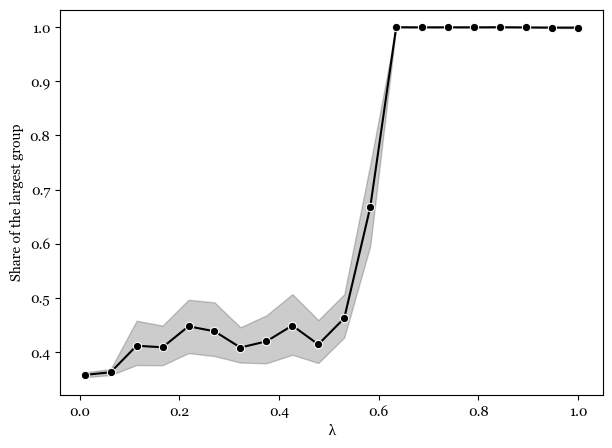

In [2]:
# Graph 3,4,5
# Showcase that the outcome of the model changes depending on the parameters

# 1) Identity 
np.random.seed(666)
seeds = list(np.arange(0,25))
params = {"seed": [int(s) for s in seeds],
          "alpha": 1/20,
          'lambda_s': np.linspace(1/100, 1, 20),
          'N':[350],
          "gamma": 1, 
          "create_network": "watts_strogatz", 
          "k": [10], 
          "p": [1/100],
          "rho": 1/3, 
          "seed_consumption": False, 
          "memory": [20]}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=1,
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
l_results_df = pd.DataFrame(results_batch)
l_results_df.to_csv("results_identity.csv")


# Plot
# Restructure data and plot
lambda_groups = l_results_df.groupby(["lambda_s", "seed"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
lambda_groups["Max share"] = lambda_groups[["Anti - environment", "Neutral", "Pro - environment"]].max(axis=1)
fig, ax = plt.subplots(figsize=(7,5))
sns.lineplot(data=lambda_groups, x="lambda_s", y="Max share", 
             color="black", 
             errorbar="ci", estimator="mean",
             marker="o", ax = ax)

ax.set_xlabel("λ") 
ax.set_ylabel("Share of the largest group") 

plt.savefig("results/lambda_thresh.pdf", bbox_inches='tight', dpi=300)

  0%|          | 0/425 [00:00<?, ?it/s]

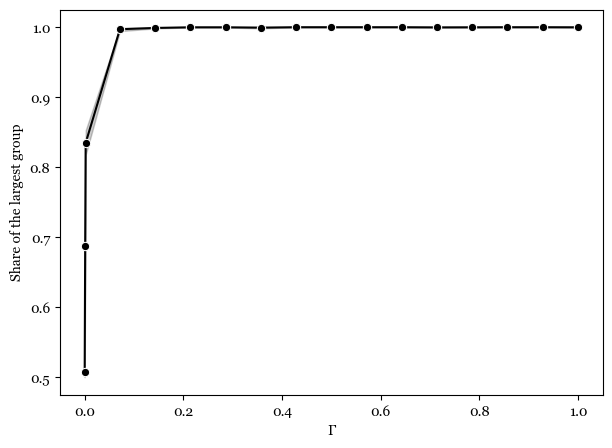

In [5]:
# 2) Gamma 
seeds = list(np.arange(0,25))
gammas = list(np.linspace(0, 1, 15))
gammas.extend([1/1000, 1/500])

np.random.seed(666)
params = {"seed": [int(s) for s in seeds], 
          "alpha": 1/20,
          'lambda_s': 1,
          'N':[350],
          "gamma": gammas,
          "create_network": "watts_strogatz", 
          "k": [10], 
          "p": [1/100],
          "rho": 1/3, 
          "seed_consumption": False, 
          "memory": [20], 
          "consumption_dist": "gamma_dist"}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=1,
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
g_results_df = pd.DataFrame(results_batch)
g_results_df.to_csv("results_gamma.csv")

# Plot
# Restructure data and plot
gamma_groups = g_results_df.groupby(["gamma", "seed"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
gamma_groups["Max share"] = gamma_groups[["Anti - environment", "Neutral", "Pro - environment"]].max(axis=1)
fig, ax = plt.subplots(figsize=(7,5))
sns.lineplot(data=gamma_groups, x="gamma", y="Max share", 
             color="black", 
             errorbar="ci", estimator="mean",
             marker="o", ax = ax)

ax.set_xlabel("Γ") 
ax.set_ylabel("Share of the largest group") 
plt.savefig("results/gamma_thresh.pdf", bbox_inches='tight', dpi=300)

In [ ]:
# 3) Rho, t and alpha 
np.random.seed(666)

params = {"seed": 666, 
          "alpha": np.linspace(0, 1, 10),
          'lambda_s': 1,
          'N':[500],
          "gamma": 1,
          "create_network": "watts_strogatz", 
          "k": [3], 
          "p": [1/100],
          "rho": np.linspace(0, 1, 10),
          "seed_consumption": False, 
          "memory": [1,5,10], 
          "wait_gamma": True}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=1, # To speed up
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
net_results_df = pd.DataFrame(results_batch)
net_results_df.to_csv("results_network.csv")

  0%|          | 0/16 [00:00<?, ?it/s]

/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Refine datasets
for i in [1,5,10]:
    df = net_results_df.loc[net_results_df.memory  == i]
    grouped = (
        df.groupby(["alpha", "rho", "iteration"])["group"]
        .value_counts(normalize=True)   # gives fraction in each group
        .unstack(fill_value=0)          # create separate columns for each group
        .reset_index()
    )

    group_columns = ["Pro - environment", "Neutral", "Anti - environment"]
    grouped["max_share"] = grouped[group_columns].max(axis=1)

    # Average across iterations
    agg_df = (
        grouped
        .groupby(["alpha", "rho"], as_index=False)["max_share"]
        .mean()
    )

    # Sort alpha and rho so meshgrid is created in ascending order
    alpha_vals = np.sort(agg_df["alpha"].unique())
    rho_vals   = np.sort(agg_df["rho"].unique())

    # Create meshgrid (X, Y)
    A, R = np.meshgrid(alpha_vals, rho_vals)

    # Pivot your aggregated DataFrame to get Z
    pivoted = agg_df.pivot(index="rho", columns="alpha", values="max_share")
    Z = pivoted.reindex(index=rho_vals, columns=alpha_vals).values


    # Plot ------------------

    fig, ax = plt.subplots(figsize=(7,5))

    # Filled contour
    levels = np.linspace(0, 1, 11)
    cs = ax.contourf(R, A, Z, levels = levels, cmap="YlGnBu")

    # Add colorbar (especially if using contourf)
    fig.colorbar(cs, ax=ax, label="Share of largest group")
    ax.set_ylabel(r"$\alpha$")
    ax.set_xlabel(r"$\rho$")
    ax.set_title(r"$\alpha$, $\rho$ and largest group share at $t^*={}$".format(i))
    plt.savefig(f"results/contour_rules__memory_{i}.pdf", bbox_inches = "tight", dpi=300)
    plt.show()


KeyError: "None of [Index(['Pro - environment', 'Neutral', 'Anti - environment'], dtype='object', name='group')] are in the [columns]"